# 🌸 Iris-Klassifikation mit Keras

## 📦 Bibliotheken importieren

In [168]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# erweiterung
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 📊 Daten laden

In [169]:
iris = load_iris()
X = iris.data
y = iris.target

print("Feature-Namen:", iris.feature_names)
print("Klassen:", iris.target_names)

Feature-Namen: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Klassen: ['setosa' 'versicolor' 'virginica']


## 🔀 Train/Test Split

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## ⚖️ Feature-Skalierung

In [185]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🧠 Modell erstellen

In [172]:
model = keras.Sequential([
    layers.Dense(32, activation='tanh'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 📒 Summary

In [173]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🚀 Training

In [174]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.4375 - loss: 0.9296 - val_accuracy: 0.5000 - val_loss: 0.8846
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5521 - loss: 0.8765 - val_accuracy: 0.6667 - val_loss: 0.8428
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7188 - loss: 0.8268 - val_accuracy: 0.7500 - val_loss: 0.8007
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7500 - loss: 0.7818 - val_accuracy: 0.8333 - val_loss: 0.7610
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7604 - loss: 0.7379 - val_accuracy: 0.8333 - val_loss: 0.7229
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7604 - loss: 0.6957 - val_accuracy: 0.8333 - val_loss: 0.6873
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7917 - loss: 0.6581 - val_accuracy: 0.8333 - val_loss: 0.6541
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8125 - loss: 0.6245 - val_accuracy: 0.8333 - val_loss:

## 📈 Plot: Accuracy & Loss

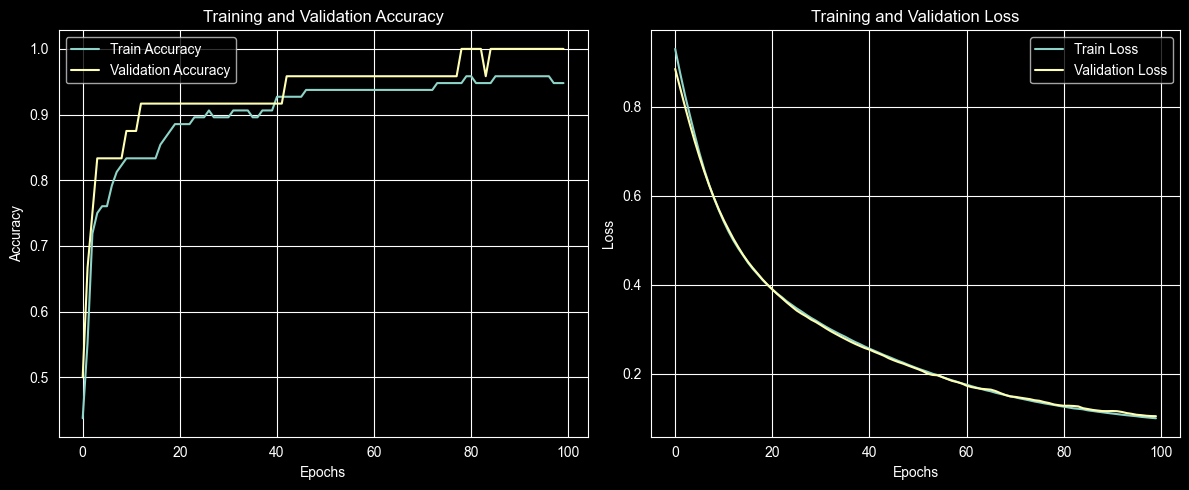

In [175]:
plt.figure(figsize=(12, 5))

# Accuracy (<-)
plt.subplot(1, 2, 1) # plt.subplot(n_filas, n_columnas, índice)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss (->)
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [176]:
# Predictions
predict = model.predict(X_test)
rounded_pred = np.argmax(predict, axis=1)
for i in rounded_pred:
    print(i)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1
0
2
1
1
0
1
2
2
1
2
0
0
0
0
1
2
1
1
2
0
2
0
2
2
2
2
2
0
0


Las curvas muestran cómo evoluciona el aprendizaje del modelo durante las épocas. Si accuracy sube y validation accuracy también, el modelo está aprendiendo bien. Si train accuracy sigue subiendo pero validation accuracy se estanca o baja, puede haber sobreajuste.

## 📲 Confusion Matrix

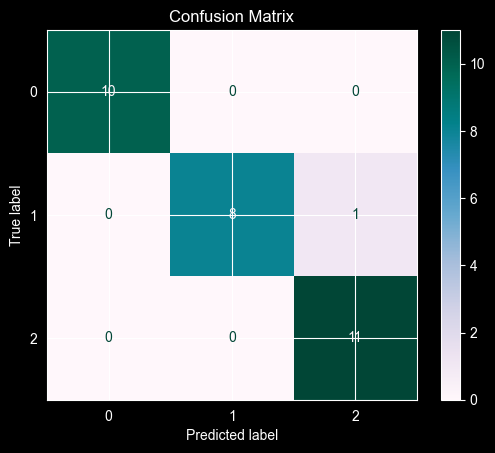

In [183]:
cm = confusion_matrix(y_test, rounded_pred)
display = ConfusionMatrixDisplay(cm, display_labels=np.arange(3))
display.plot(cmap="PuBuGn", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## ✅ Evaluate

In [184]:
loss, acc = model.evaluate(X_test, y_test)
print("*-*" * 10)
print("Test Accuracy:", acc)
print("*-*" * 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9667 - loss: 0.0813
*-**-**-**-**-**-**-**-**-**-*
Test Accuracy: 0.9666666388511658
*-**-**-**-**-**-**-**-**-**-*


# ML Modelle Trainieren und Evaluieren

## Logistic Regression

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

print("y_pred [1]= ", y_pred_log_reg[1])

In [ ]:
print("y_test [1]= ", y_test[1]) # para comparar con y_pred_log_reg

In [ ]:
print(classification_report(y_test, y_pred_log_reg))

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

## Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print("\n\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

## SVC

In [ ]:
svc = SVC()
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred_svc))
print("\nClassification_report: \n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# -------------------------------------------------------------------------------------------------- #

## 📝 Aufgaben
1. Ändere die Anzahl der Neuronen.
2. Teste andere Aktivierungsfunktionen.
3. Erhöhe die Anzahl der Epochen.
4. Visualisiere den Trainingsverlauf.
5. Recherchiere das Dataset in scikit-learn. Eckdaten
6. Recherchiere den StandardScaler.

## 1.    Neuronen Base (16, 16, 3) = TA: 0,96
    A- change (32, 16, 3) = TA: 1,0
    B- change (64, 32, 3) = TA: 0,89
    C- change (16, 32, 3) = TA: 0,83

Aumentar neuronas no garantiza mejor rendimiento. En este caso, una arquitectura moderada como (32,16,3) funcionó mejor que configuraciones más grandes, lo que sugiere que modelos más complejos pueden sobreajustarse o volverse inestables en un dataset pequeño como Iris.

## 2.    AF Base (relu, relu, softmax)    = TA: 0,96
    A- change (tanh, relu, softmax)    = TA: 1,0
    B- change (sigmoid, relu, softmax) = TA: 0,63
    C- change (relu, sigmoid, softmax) = TA: 0,63
    D- change (relu, tanh, softmax)    = TA: 0,89

tanh + relu dio mejor resultado que la configuración base en esta partición concreta. Las combinaciones con sigmoid bajaron bastante la accuracy, probablemente porque sigmoid puede saturarse más fácilmente y aprender peor en este problema.

## 3.    Epoch Base (50) = TA: 0,96
    A. change (60)  = TA: 1,0
    B. change (75)  = TA: 1,0
    C. change (100) = TA: 1,0

Aumentar épocas mejoró la accuracy en este split hasta llegar a 1.0, pero no necesariamente implica una mejora generalizable. Sería recomendable revisar también la curva de validation loss/accuracy para comprobar si hay sobreajuste.

## 5. Rechercher das Dataset in scikit-learn. Eckdaten

Iris Dataset – Eckdaten
Nombre: Iris Dataset
Fuente: introducido por Ronald Fisher en 1936
Incluido en: sklearn.datasets.load_iris()

Número de muestras: 150

### Número de características: 4
```
Características:
 - sepal length (cm)
 - sepal width (cm)
 - petal length (cm)
 - petal width (cm)
```

### Número de clases: 3
```
Clases objetivo:
 - setosa
 - versicolor
 - virginica
```

Muestras por clase: 50 por cada clase
Tipo de problema: clasificación multiclase
Ventaja del dataset: pequeño, limpio y muy usado para aprender clasificación
Limitación: es demasiado simple para evaluar modelos modernos de forma seria

In [ ]:
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Target names:", iris.target_names)
print("Feature names:", iris.feature_names)

El dataset Iris es ideal para ejercicios introductorios de clasificación porque es pequeño, equilibrado y fácil de interpretar

## 6. Rechercher den StandardScaler

StandardScaler – Erklärung

## StandardScaler es una herramienta de scikit-learn que estandariza las variables numéricas.

Transforma cada feature para que tenga aproximadamente:

media = 0
desviación estándar = 1

La fórmula es:

    𝑧  = (𝑥 − 𝜇) / 𝜎

donde:

```
    𝑥 = valor original,
    𝜇 = media de la variable,
    𝜎 = desviación estándar.
```


### ¿Por qué se usa?

Porque muchas redes neuronales y algoritmos de machine learning funcionan mejor cuando las variables están en escalas parecidas. Si una variable tiene valores muy grandes y otra muy pequeños, el entrenamiento puede volverse menos estable.

En este ejercicio

En Iris, las 4 variables están en centímetros, pero aun así sus rangos no son exactamente iguales. Escalarlas ayuda a que el modelo aprenda de forma más equilibrada.

## Importante

```El scaler se ajusta solo con los datos de entrenamiento:```
> scaler.fit(X_train)

```y luego se aplica a train y test:```
>    X_train = scaler.transform(X_train)

>    X_test = scaler.transform(X_test)

```o directamente:```
> X_train = scaler.fit_transform(X_train)

> X_test = scaler.transform(X_test)

### Esto evita data leakage.